In [2]:
import pandas as pd

v1 = pd.read_csv("./results/betas.csv")
v2 = pd.read_csv("./results/betas_v2.csv")
v3 = pd.read_csv("./results/betas_v3.csv")
v4 = pd.read_csv("./results/betas_no_transdia.csv")

Pairwise correlations:
          v1        v2        v3        v4
v1  1.000000 -1.000000 -0.983309 -0.984791
v2 -1.000000  1.000000  0.983309  0.984791
v3 -0.983309  0.983309  1.000000  0.996633
v4 -0.984791  0.984791  0.996633  1.000000


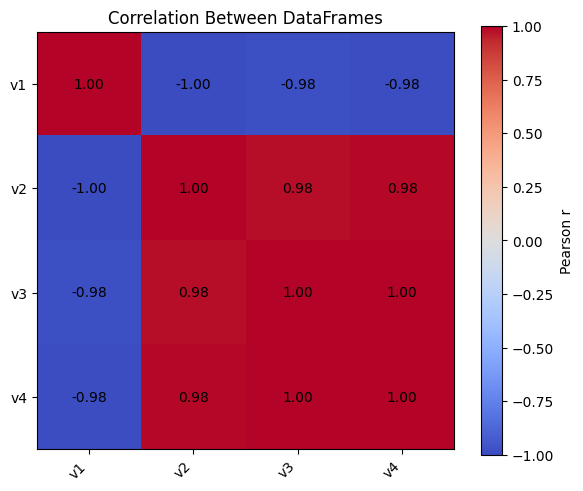

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Put all dataframes in one dictionary for easier handling
dfs = {"v1": v1, "v2": v2, "v3": v3, "v4": v4}

def pick_numeric_series(df):
    """Pick a comparable numeric column from each dataframe."""
    preferred = ["correlation", "diagnosis_beta"]
    for col in preferred:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            return df[col]

    numeric_cols = df.select_dtypes(include="number").columns
    if len(numeric_cols) == 0:
        raise ValueError("No numeric columns found in dataframe")
    return df[numeric_cols[0]]

# Build aligned matrix of beta-like vectors
series_dict = {name: pick_numeric_series(df).reset_index(drop=True) for name, df in dfs.items()}
combined = pd.DataFrame(series_dict).dropna()

# Pairwise correlation between each dataframe
corr_mat = combined.corr(method="pearson")
print("Pairwise correlations:")
print(corr_mat)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_mat.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_mat.columns)))
ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_mat.index)))
ax.set_yticklabels(corr_mat.index)
ax.set_title("Correlation Between DataFrames")

# Annotate values
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        ax.text(j, i, f"{corr_mat.iloc[i, j]:.2f}", ha="center", va="center", color="black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson r")
plt.tight_layout()
plt.show()